# Random Forest 

U ovoj svesci primenjuje se Random Forest regresioni model za predviđanje koncentracije PM2.5. Random Forest kombinuje veći broj stabala odlučivanja i omogućava modelovanje složenih i nelinearnih odnosa između ulaznih atributa i ciljne promenljive.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import metrics
from sklearn import ensemble

import seaborn as sns

# Učitavanje skupa podataka

In [5]:
data = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

# Pretprocesiranje podataka

In [6]:
data = data.drop(columns=['No'])
data = data.dropna(subset=['pm2.5'])
data = pd.get_dummies(data, columns=['cbwd'], dtype=int)

Ulazni atributi izdvajaju se u skup `x`, dok ciljnu promenljivu `y` predstavlja koncentracija PM2.5.

In [7]:
x = data.drop(columns=['pm2.5'])
y = data['pm2.5']

In [8]:
x.shape

(41757, 14)

In [9]:
y.shape

(41757,)

In [10]:
feature_names = x.columns
number_of_features = len(feature_names)

## Podela podataka

Podaci se dele na trening, validacioni i test skup. Trening skup koristi se za obučavanje modela, validacioni skup za izbor hiperparametara, dok se test skup koristi za konačnu evaluaciju izabranog modela.

In [11]:
x_train_val, x_test, y_train_val, y_test = model_selection.train_test_split(x, y, test_size=0.33, random_state=7)

In [12]:
x_train, x_val, y_train, y_val = model_selection.train_test_split(x_train_val, y_train_val, train_size=0.8, random_state=7)

# Početni Random Forest model

Najpre se formira Random Forest regresioni model sa 100 stabala. Model se obučava na trening skupu, a njegove početne performanse procenjuju se na validacionom skupu.

In [13]:
model_forest = ensemble.RandomForestRegressor(n_estimators=100, random_state=7)

In [14]:
model_forest.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [15]:
y_val_pred = model_forest.predict(x_val)

In [16]:
print('R2:', metrics.r2_score(y_val, y_val_pred))
print('MAE:', metrics.mean_absolute_error(y_val, y_val_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_val, y_val_pred)))

R2: 0.8021229622756272
MAE: 25.20166904932094
RMSE: 39.76291856511915


Početni Random Forest model na validacionom skupu ostvaruje R² vrednost od približno 0,802, MAE od 25,20 i RMSE od 39,76.

Model objašnjava približno 80% varijabilnosti ciljne promenljive, što ukazuje na dobre performanse Random Forest modela pri predviđanju koncentracije PM2.5. U narednom koraku ispituju se različite vrednosti hiperparametara kako bi se proverilo da li je moguće dodatno poboljšati performanse modela.

## Podešavanje hiperparametara

Performanse Random Forest modela zavise od izbora njegovih hiperparametara. U ovom slučaju ispituju se različite vrednosti broja stabala (`n_estimators`) i maksimalne dubine stabala (`max_depth`).

Za svaku kombinaciju hiperparametara model se obučava na trening skupu i računa se R² vrednost na validacionom skupu. Za najbolju kombinaciju bira se ona koja ostvaruje najveću R² vrednost.

In [ ]:
n_estimators_values = [50, 100, 200]
max_depth_values = [5, 10, 20, None]

rf_scores = np.zeros((len(n_estimators_values), len(max_depth_values)))

best_r2 = -np.inf
best_n_estimators = None
best_max_depth = None

for i, n in enumerate(n_estimators_values):
    for j, depth in enumerate(max_depth_values):
        model = ensemble.RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=7)
        model.fit(x_train, y_train)
        y_val_pred = model.predict(x_val)
        r2 = metrics.r2_score(y_val, y_val_pred)

        rf_scores[i, j] = r2          

        if r2 > best_r2:
            best_r2 = r2
            best_n_estimators = n
            best_max_depth = depth

## Grafički prikaz R² score-a za različite vrednosti broja stabala i maksimalne dubine

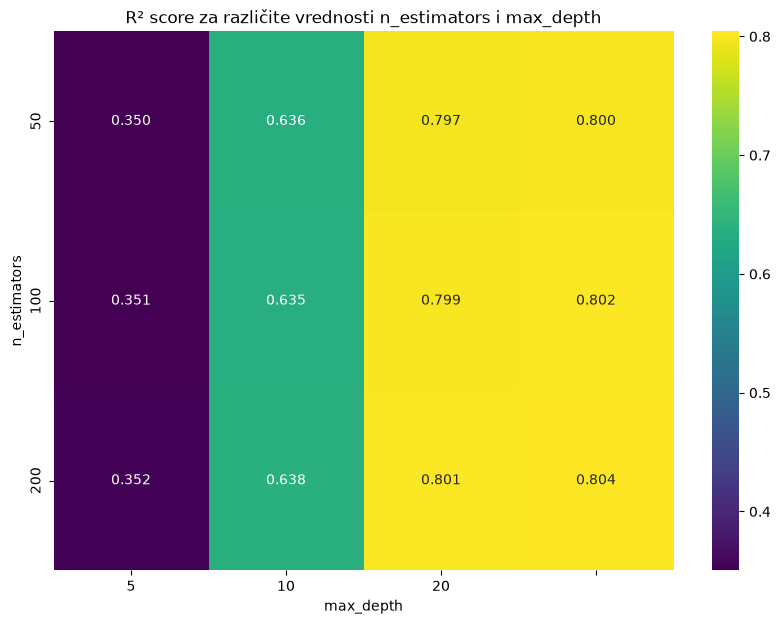

In [34]:
plt.figure(figsize=(10, 7))

sns.heatmap(rf_scores, annot=True, fmt='.3f', xticklabels=max_depth_values, yticklabels=n_estimators_values, cmap='viridis')
plt.xlabel('max_depth')
plt.ylabel('n_estimators')
plt.title('R² score za različite vrednosti n_estimators i max_depth')
plt.show()

Na heat mapi je prikazano kako broj stabala n_estimators i dozvoljena dubina max_depth utiču na R², gde veće vrednosti oba parametra vode ka boljim performansama.

In [36]:
print('Najbolji n_estimators:', best_n_estimators)
print('Najbolji max_depth:', best_max_depth)
print('Najbolji validation R2:', best_r2)

Najbolji n_estimators: 200
Najbolji max_depth: None
Najbolji validation R2: 0.8041522035598938


Najbolji rezultat na validacionom skupu ostvaren je za `n_estimators = 200` i `max_depth = None`, pri čemu R² iznosi približno 0,804.

U odnosu na početni Random Forest model sa 100 stabala, čija je R² vrednost iznosila približno 0,802, podešavanje hiperparametara dovelo je do veoma malog poboljšanja performansi. Izabrana kombinacija hiperparametara koristi se za formiranje konačnog Random Forest modela.

Vrednost max_depth=None znači da dubina stabala nije ograničena, odnosno da se svako stablo razvija sve dok se ne postigne potpuno razdvajanje podataka ili dok svi listovi ne postanu čisti.

# Evaluacija najboljeg Random Forest modela

Na osnovu najboljih hiperparametara formira se Random Forest model koji se obučava na trening skupu. Njegove konačne performanse zatim se procenjuju na test skupu, koji nije korišćen prilikom izbora hiperparametara.

In [20]:
best_forest = ensemble.RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=7)

In [21]:
best_forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [22]:
y_test_pred = best_forest.predict(x_test)

In [23]:
print('Random Forest - TEST')

R2 = metrics.r2_score(y_test, y_test_pred)
print('R2:', R2)
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred))
print( 'RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

Random Forest - TEST
R2: 0.7987062498074355
MAE: 25.66472423802612
RMSE: 41.9015004976553


Najbolji Random Forest model na test skupu ostvaruje R² vrednost od približno 0,799, MAE od 25,66 i RMSE od 41,90.

Model objašnjava približno 80% varijabilnosti ciljne promenljive. R² vrednost na test skupu veoma je slična vrednosti dobijenoj na validacionom skupu, što pokazuje da model zadržava dobre performanse na podacima koji nisu korišćeni prilikom izbora hiperparametara.

## Važnost atributa

Random Forest omogućava procenu relativne važnosti ulaznih atributa za formiranje predviđanja. Važnost atributa određuje koliko pojedinačni atribut doprinosi odlukama koje stabla donose tokom formiranja modela.

U narednom koraku prikazuje se važnost svih ulaznih atributa prema obučenom Random Forest modelu.

In [24]:
feature_importances = best_forest.feature_importances_
importance = pd.Series( feature_importances,index=feature_names).sort_values()

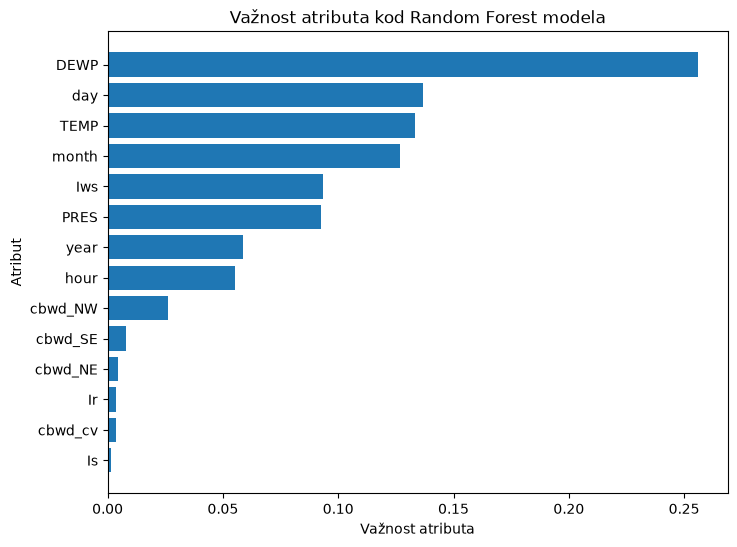

In [25]:
plt.figure(figsize=(8, 6))
plt.barh(importance.index, importance.values)
plt.xlabel('Važnost atributa')
plt.ylabel('Atribut')
plt.title('Važnost atributa kod Random Forest modela')
plt.show()

Grafički prikaz pokazuje da svi atributi nemaju podjednak značaj za predviđanje koncentracije PM2.5. Pojedini atributi imaju znatno veći doprinos predviđanju modela, dok je uticaj drugih atributa manji.

Ovakav rezultat pokazuje da Random Forest model pri formiranju predviđanja u većoj meri koristi informacije sadržane u određenim vremenskim i meteorološkim atributima.

# Evaluacija najboljeg Random Forest  na uniji trening i validacionog skupa

In [26]:
best_forest_train_val = ensemble.RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=7)
best_forest_train_val.fit(x_train_val, y_train_val)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [27]:
y_test_pred_train_val = best_forest_train_val.predict(x_test)

In [28]:
print('Random Forest - TEST - trening i validacija')

R2_union = metrics.r2_score(y_test, y_test_pred_train_val)
print('R2:', R2_union)
print('MAE:', metrics.mean_absolute_error(y_test, y_test_pred_train_val))
print( 'RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_train_val)))

Random Forest - TEST - trening i validacija
R2: 0.8277673672531031
MAE: 23.488123004354133
RMSE: 38.7589630938063


## Grafički prikaz poređenja modela

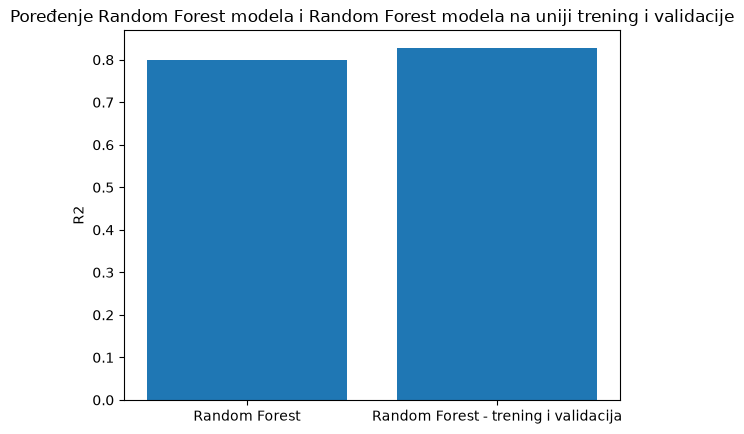

In [29]:
models = ['Random Forest', 'Random Forest - trening i validacija']
scores = [R2, R2_union]

plt.bar(models, scores)
plt.ylabel('R2')
plt.title('Poređenje Random Forest modela i Random Forest modela na uniji trening i validacije')
plt.show()

Osnovni Random Forest model na test skupu ostvaruje R² od približno 0.80, MAE od oko 25.7 i RMSE od oko 41,9 ,dok model treniran na uniji trening i validacionog skupa postiže bolje rezultate u sve tri metrike, sa R² od približno 0,83, MAE od oko 23,5 i RMSE od oko 38,8. Ovakvo poboljšanje ukazuje na to da dodatni podaci iz validacionog skupa doprinose smanjenju greške i tačnijem predviđanju.

## Čuvanje modela

In [30]:
import joblib

In [31]:
joblib.dump(best_forest, "../models/05_RandomForest.pkl")
joblib.dump(best_forest_train_val, "../models/05_RandomForest_TrainVal.pkl")

['../models/05_RandomForest_TrainVal.pkl']